# 2025-26 Filtered Baseline — The Classify Population and Its Price

**Objective:** The quotable numbers for the pre-batch decision ("submitting N comments,
expect $X") and, later, the launch methodology. Runs on the final population
(config v4.1 re-filter, verified by 03); with #29/#63 merged, this is the last document
before batch submission. Parallels 02 (corpus baseline) one stage downstream.
Deliverable: this notebook + small derived parquets under
`data/2025-26/reference/coverage/`.

**This notebook answers:**

- §1 — What is the final classify population, and how does the match rate compare to
  the floor, the corpus, and v1's filter stage?
- §2 — How many players does a typical kept comment mention?
- §3 — How is player volume distributed: who qualifies, how concentrated is discourse?
- §4 — What share of the classify population carries a resolvable `fan_team` flair?
- §5 — What will classification cost? (v1-02 §1.4's deferred estimate, finally on the
  actual population)

## Load Data

Reuse-first: §1–§3 read the artifacts 03 already persisted from this exact file
(`mentions_census`, `mentions_per_comment`, `player_mention_counts`) plus 02's corpus
census for denominators — zero new scans. Only two passes over the 975 MB mentions file
are new: §4 (flair) and §5 (body length). One extra count-only scan of the v1 filtered
file gives the YoY filter-stage comparison.

Guardrails:

- **`body` never materializes.** §5 computes `strlen(body)` inside the scan and groups
  by it — no body value ever leaves the reader, not even into a temp table.
- Every scan cell is guarded on artifact existence with a staleness warning against the
  mentions file; the reused 03 artifacts get the same check, so a future re-filter
  flags every consumer here too.
- Cost constants come from `pipeline/batch.py` (production), not hand-rolled numbers —
  verified against current Anthropic Batch pricing (Haiku 4.5 $1/$5 standard, 50%
  batch discount) on 2026-07-07.

In [1]:
import os
import sys
from pathlib import Path

# Bootstrap: run from anywhere (see 01/02/03 — walk up to the repo root, chdir).
_root = Path.cwd()
while not (_root / "pyproject.toml").exists() and _root != _root.parent:
    _root = _root.parent
os.chdir(_root)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import duckdb
import matplotlib.pyplot as plt
import polars as pl

from pipeline.aggregation import extract_team_from_flair
from pipeline.batch import (
    INPUT_COST_PER_MTOK,
    MODEL,
    OUTPUT_COST_PER_MTOK,
    build_prompt,
    calculate_cost,
)
from utils.paths import get_data_dir
from utils.player_config import load_player_config
from utils.season_config import get_active_season
from utils.team_config import build_alias_to_team_map

SEASON = "2025-26"  # pinned: this notebook is season-scoped (notebooks/2025-26/)
assert get_active_season() == SEASON, "active season flipped — review before re-running"

MENTIONS_RAW = get_data_dir(season=SEASON) / "filtered" / "r_nba_player_mentions.jsonl"
V1_MENTIONS_RAW = get_data_dir(season="2024-25") / "filtered" / "r_nba_player_mentions.jsonl"
CORPUS_DIR = get_data_dir(season=SEASON) / "reference" / "corpus"
COVERAGE_DIR = get_data_dir(season=SEASON) / "reference" / "coverage"
assert MENTIONS_RAW.exists(), f"missing mentions file: {MENTIONS_RAW}"


def warn_if_stale(pq: Path, raw: Path) -> None:
    """Companion to the existence-only reuse guards: flag a persisted
    artifact older than the file it derives from."""
    if pq.exists() and pq.stat().st_mtime < raw.stat().st_mtime:
        print(f"WARNING: {pq.name} predates {raw.name} — delete it to force a rescan")


# Reused artifacts — 02's corpus census (denominators) and 03's filtered-file
# stats (this file's row grain, already scanned post-re-filter).
CENSUS_02 = CORPUS_DIR / "comments_census.parquet"
V1_CENSUS_02 = CORPUS_DIR / "v1_comments_census.parquet"
YIELD_03 = COVERAGE_DIR / "mentions_census.parquet"
NPLAYERS_03 = COVERAGE_DIR / "mentions_per_comment.parquet"
COUNTS_03 = COVERAGE_DIR / "player_mention_counts.parquet"
for _pq in (YIELD_03, NPLAYERS_03, COUNTS_03):
    assert _pq.exists(), f"missing 03 artifact: {_pq} — run 03_filter_coverage first"
    warn_if_stale(_pq, MENTIONS_RAW)

corpus = pl.read_parquet(CENSUS_02).row(0, named=True)
v1_corpus = pl.read_parquet(V1_CENSUS_02).row(0, named=True)
myield = pl.read_parquet(YIELD_03).row(0, named=True)
M_TOTAL = myield["n_rows"]

V1_PLAYER_OVERALL = get_data_dir(season="2024-25") / "dashboard" / "player_overall.parquet"
V1_ATTRIBUTED = int(
    duckdb.sql(f"SELECT sum(comment_count) AS n FROM '{V1_PLAYER_OVERALL}'").pl()["n"][0]
)

players, short_aliases = load_player_config()
TEAM_MAP = build_alias_to_team_map()
QUALIFIED_BAR = 5_000

duckdb.sql("SET temp_directory = '/tmp/duckdb_baseline_spill'")

print(f"Classify population: {M_TOTAL:,} comments (config v4.1 re-filter)")
print(f"Corpus total (02):   {corpus['n_comments']:,}")
print(f"Model / batch price: {MODEL}  (${INPUT_COST_PER_MTOK}/MTok in, ${OUTPUT_COST_PER_MTOK}/MTok out)")

Classify population: 2,110,485 comments (config v4.1 re-filter)
Corpus total (02):   7,283,478
Model / batch price: claude-haiku-4-5-20251001  ($0.5/MTok in, $2.5/MTok out)


## 1. Yield & match rate — the population, in context

Three comparisons give the headline its meaning: the **v1-rate floor** (what the corpus
would yield at v1's measured match rate), the **corpus share** (how much of r/NBA talks
about tracked players at all), and the **v1 filter stage** (the true YoY population
comparison — v1's filtered file, counted once here).

In [2]:
# §1 — the ONE count-only scan of the v1 filtered file (891 MB; id projected).
V1F_PQ = CORPUS_DIR / "v1_filtered_census.parquet"

if not V1F_PQ.exists():
    duckdb.sql(f"""
        COPY (
            SELECT count(*) AS n_rows, count(DISTINCT id) AS n_distinct_ids
            FROM read_ndjson('{V1_MENTIONS_RAW}',
                format = 'newline_delimited',
                columns = {{id: 'VARCHAR'}})
        ) TO '{V1F_PQ}' (FORMAT parquet)
    """)
    print("scanned v1 filtered file ONCE; census persisted")
else:
    print("reusing persisted v1 filtered census (no rescan)")
warn_if_stale(V1F_PQ, V1_MENTIONS_RAW)

v1f = pl.read_parquet(V1F_PQ).row(0, named=True)

v1_match_rate = V1_ATTRIBUTED / v1_corpus["n_comments"]
floor = v1_match_rate * corpus["n_comments"]
match_rate = M_TOTAL / corpus["n_comments"]
v1_filter_rate = v1f["n_rows"] / v1_corpus["n_comments"]

print("=== the quotables ===")
print(f"classify population:   {M_TOTAL:,} comments")
print(f"match rate:            {match_rate:.1%} of the {corpus['n_comments']:,} corpus")
print(f"vs v1-rate floor:      {floor:,.0f} → {(M_TOTAL / floor - 1):+.1%} above "
      "(the config broadening, measured)")
print(f"v1 filter stage:       {v1f['n_rows']:,} rows ({v1_filter_rate:.1%} of v1 corpus)")
print(f"YoY population:        {(M_TOTAL / v1f['n_rows'] - 1):+.1%}")
print(f"note: v1 attributed ({V1_ATTRIBUTED:,}) is post-classification — the filter-stage "
      "comparison above is the like-for-like one")

reusing persisted v1 filtered census (no rescan)
=== the quotables ===
classify population:   2,110,485 comments
match rate:            29.0% of the 7,283,478 corpus
vs v1-rate floor:      1,621,657 → +30.1% above (the config broadening, measured)
v1 filter stage:       1,939,290 rows (27.5% of v1 corpus)
YoY population:        +8.8%
note: v1 attributed (1,567,722) is post-classification — the filter-stage comparison above is the like-for-like one


## 2. Mentions per comment — the shape of a kept comment

Reused from 03's row-grain pass. Context for what classification does with this: the
classifier returns **one** `sentiment_player` per comment (the model names the player
it reads the comment as being about), so multi-mention comments contribute one
attributed reading, not one per mentioned player — `mentioned_players` is the
population/coverage field, attribution happens at the model.

In [3]:
# §2 — no scan; 03's artifact.
nplayers = pl.read_parquet(NPLAYERS_03)

_single = nplayers.filter(pl.col("n_players") == 1)["n_rows"].sum()
_multi = M_TOTAL - _single
_mean = (nplayers["n_players"] * nplayers["n_rows"]).sum() / M_TOTAL
_max = nplayers["n_players"].max()

print(f"single-mention: {_single:,} ({_single / M_TOTAL:.1%})")
print(f"multi-mention:  {_multi:,} ({_multi / M_TOTAL:.1%})")
print(f"mean players/comment: {_mean:.2f}; max: {_max} (list-every-player copypasta tail)")
display(
    nplayers.sort("n_players")
    .head(8)
    .with_columns((pl.col("n_rows") / M_TOTAL).round(4).alias("share"))
)

single-mention: 1,512,790 (71.7%)
multi-mention:  597,695 (28.3%)
mean players/comment: 1.45; max: 106 (list-every-player copypasta tail)


n_players,n_rows,n_distinct_ids,min_utc,max_utc,share
i64,i64,i64,i64,i64,f64
1,1512790,1512790,1759291237,1782791970,0.7168
2,411114,411114,1759291245,1782791951,0.1948
3,109155,109155,1759291397,1782791975,0.0517
4,41242,41242,1759291966,1782791688,0.0195
5,17407,17407,1759293194,1782789940,0.0082
6,8092,8092,1759292139,1782789203,0.0038
7,4115,4115,1759317521,1782782706,0.0019
8,2299,2299,1759322239,1782782087,0.0011


## 3. Player volume distribution — who qualifies, how concentrated

Reused from 03's exploded pass. The 5,000-comment qualified bar is the published
threshold (`manifest.json`'s future single home). Concentration matters for launch
framing: if the top 10 players hold most of the discourse, "most hated" is a
story about a small cast.

tracked players:  223 (of 223 in config)
qualified (≥5,000): 104
median player:    4,238 mentions
top 10 share:     40.2% of all mentions
top 25 share:     60.3% of all mentions
top 50 share:     77.1% of all mentions


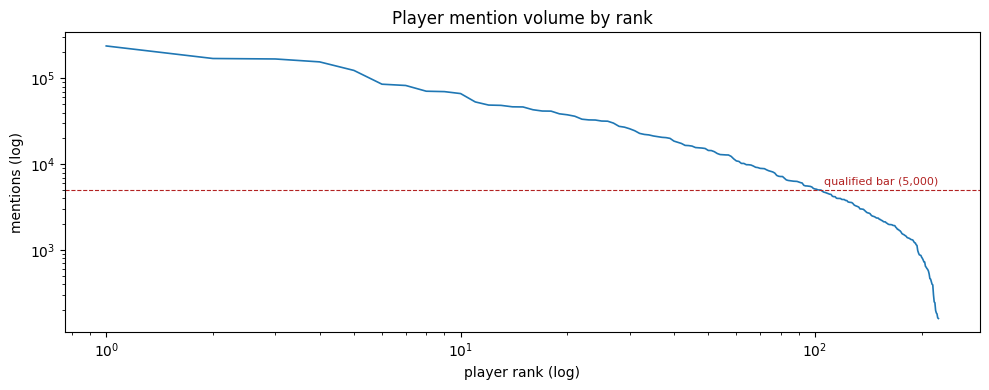

player,mentions
str,i64
"""Victor Wembanyama""",238235
"""Shai Gilgeous-Alexander""",170210
"""LeBron James""",168088
"""Luka Doncic""",155498
"""Nikola Jokic""",123654
"""Giannis Antetokounmpo""",85471
"""Stephen Curry""",82592
"""Jalen Brunson""",70819
"""Kevin Durant""",70056


In [4]:
# §3 — no scan; 03's artifact.
counts = pl.read_parquet(COUNTS_03).sort("mentions", descending=True)
_total_mentions = counts["mentions"].sum()
_qualified = counts.filter(pl.col("mentions") >= QUALIFIED_BAR)

print(f"tracked players:  {counts.height} (of {len(players)} in config)")
print(f"qualified (≥{QUALIFIED_BAR:,}): {_qualified.height}")
print(f"median player:    {counts['mentions'].median():,.0f} mentions")
for _n in (10, 25, 50):
    _share = counts.head(_n)["mentions"].sum() / _total_mentions
    print(f"top {_n:>2} share:     {_share:.1%} of all mentions")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, counts.height + 1), counts["mentions"], lw=1.2)
ax.axhline(QUALIFIED_BAR, color="firebrick", ls="--", lw=0.8)
ax.text(counts.height, QUALIFIED_BAR * 1.15, "qualified bar (5,000)",
        ha="right", fontsize=8, color="firebrick")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("player rank (log)")
ax.set_ylabel("mentions (log)")
ax.set_title("Player mention volume by rank")
plt.tight_layout()
plt.show()

display(counts.head(10))

## 4. Flair coverage among matched — the `fan_team` denominator, filtered stage

02 measured flair on the whole corpus (62.9%); this section measures it on the
classify population. The delta answers a real question — do flaired (team-affiliated)
users engage in player discourse more than the unflaired? — and the resolver-weighted
number is the true `fan_team` denominator every fanbase view will divide by.

In [5]:
# §4 scan — the ONE flair pass over the mentions file. body not projected.
FLAIR_CENSUS_PQ = COVERAGE_DIR / "filtered_flair_census.parquet"
FLAIR_VALUES_PQ = COVERAGE_DIR / "filtered_flair_values.parquet"
FLAIR_TOP_N = 1000  # persisted cap; the tail is reported, not silent

if not (FLAIR_CENSUS_PQ.exists() and FLAIR_VALUES_PQ.exists()):
    _scan = duckdb.sql(f"""
        SELECT
            grouping(flair) = 1 AS is_total,
            flair,
            count(*)            AS n,
            count(DISTINCT flair) AS n_distinct_flairs,
            count(*) FILTER (WHERE flair IS NULL) AS null_flair
        FROM (
            SELECT author_flair_text AS flair
            FROM read_ndjson('{MENTIONS_RAW}',
                format = 'newline_delimited',
                columns = {{author_flair_text: 'VARCHAR'}})
        )
        GROUP BY GROUPING SETS ((flair), ())
    """).pl()
    _scan.filter(pl.col("is_total")).drop("is_total", "flair").write_parquet(FLAIR_CENSUS_PQ)
    _values = (
        _scan.filter(~pl.col("is_total") & pl.col("flair").is_not_null())
        .select("flair", "n")
        .sort("n", descending=True)
    )
    _values.head(FLAIR_TOP_N).write_parquet(FLAIR_VALUES_PQ)
    print(f"scanned mentions file; flair census + values persisted "
          f"({_values.height:,} distinct, top {FLAIR_TOP_N} kept)")
else:
    print("reusing persisted flair artifacts (no rescan)")
for _pq in (FLAIR_CENSUS_PQ, FLAIR_VALUES_PQ):
    warn_if_stale(_pq, MENTIONS_RAW)

fcensus = pl.read_parquet(FLAIR_CENSUS_PQ).row(0, named=True)
fvalues = pl.read_parquet(FLAIR_VALUES_PQ)
# Cross-pass consistency stays HARD (scan disagreement = corruption signal).
assert fcensus["n"] == M_TOTAL, "flair-scan rows != 03 census rows"

flaired = fcensus["n"] - fcensus["null_flair"]
corpus_flair_rate = 1 - corpus["null_flair"] / corpus["n_comments"]

# Resolver-weighted fan_team coverage — production resolver, same as 02 §1.2.
fvalues = fvalues.with_columns(
    pl.col("flair")
    .map_elements(lambda f: extract_team_from_flair(f, TEAM_MAP), return_dtype=pl.String)
    .alias("resolved_team")
)
_top_mass = fvalues["n"].sum()
_resolved_mass = fvalues.filter(pl.col("resolved_team").is_not_null())["n"].sum()

print(f"flair coverage (matched set): {flaired:,} / {M_TOTAL:,} = {flaired / M_TOTAL:.1%}")
print(f"flair coverage (corpus, 02):  {corpus_flair_rate:.1%} → "
      f"delta {(flaired / M_TOTAL - corpus_flair_rate) * 100:+.1f} pp")
print(f"resolver match over top-value mass ({_top_mass / flaired:.1%} of flaired): "
      f"{_resolved_mass / _top_mass:.1%}")
print(f"fan_team denominator: ≈{_resolved_mass / M_TOTAL:.1%} of the classify population "
      "carries a resolvable fanbase")

scanned mentions file; flair census + values persisted (1,734 distinct, top 1000 kept)
flair coverage (matched set): 1,362,577 / 2,110,485 = 64.6%
flair coverage (corpus, 02):  62.9% → delta +1.7 pp
resolver match over top-value mass (99.8% of flaired): 93.4%
fan_team denominator: ≈60.2% of the classify population carries a resolvable fanbase


## 5. Token & cost estimation — v1-02 §1.4, at its correct home

v1-02 estimated cost on the *cleaned corpus* under hypothetical filter scenarios; this
runs the same machinery on the actual classify population. Two deliberate choices:

- **Production constants, not hand-rolled numbers** — model, batch prices, and
  `calculate_cost` come from `pipeline/batch.py`; the prompt overhead is *measured*
  from the production `build_prompt`. If batch.py reprices, this cell reprices.
- **A sensitivity band, not v1 actuals** — v1-04's measured tokens (209-token overhead,
  ~112 output tokens) describe the old verbose prompt, superseded by the current
  minimal template; they'd anchor the estimate high. Instead: chars/token at
  3.5/4.0/4.5 and output tokens at 10/15/20 bracket the answer. #63's
  `summarize_actual_usage` closes the loop with real numbers after the first batch.

scanned mentions file; body-length distribution persisted
total body chars: 337,964,496
mean 160 | median 98 | p95 495 | p99 949 | max 9,961


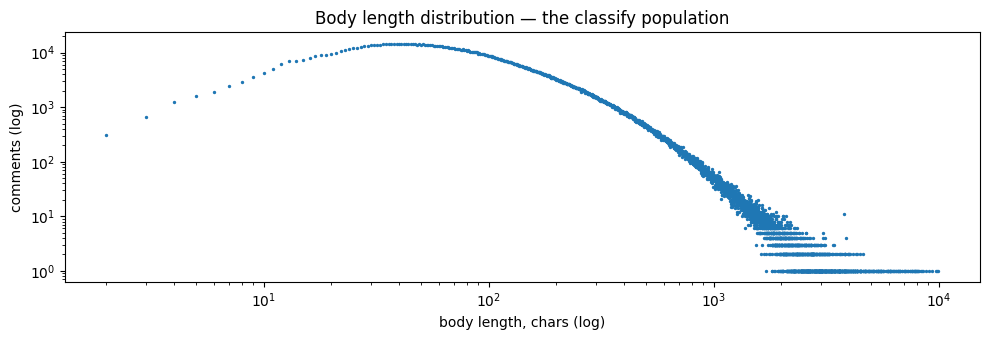

In [6]:
# §5 scan — the ONE body pass. strlen computed inside the scan; the body value
# itself never leaves the reader.
LENGTHS_PQ = COVERAGE_DIR / "body_length_distribution.parquet"

if not LENGTHS_PQ.exists():
    duckdb.sql(f"""
        COPY (
            SELECT strlen(body) AS n_chars, count(*) AS n
            FROM read_ndjson('{MENTIONS_RAW}',
                format = 'newline_delimited',
                columns = {{body: 'VARCHAR'}})
            GROUP BY n_chars
        ) TO '{LENGTHS_PQ}' (FORMAT parquet)
    """)
    print("scanned mentions file; body-length distribution persisted")
else:
    print("reusing persisted length distribution (no rescan)")
warn_if_stale(LENGTHS_PQ, MENTIONS_RAW)

lengths = pl.read_parquet(LENGTHS_PQ).sort("n_chars")
# Cross-pass consistency stays HARD.
assert lengths["n"].sum() == M_TOTAL, "length-scan rows != 03 census rows"

TOTAL_BODY_CHARS = (lengths["n_chars"] * lengths["n"]).sum()
_cum = lengths.with_columns(pl.col("n").cum_sum().alias("cum"))


def chars_pctile(q: float) -> int:
    """Exact weighted percentile from the grouped length distribution."""
    return _cum.filter(pl.col("cum") >= q / 100 * M_TOTAL)["n_chars"][0]


print(f"total body chars: {TOTAL_BODY_CHARS:,}")
print(f"mean {TOTAL_BODY_CHARS / M_TOTAL:,.0f} | median {chars_pctile(50):,} | "
      f"p95 {chars_pctile(95):,} | p99 {chars_pctile(99):,} | max {lengths['n_chars'].max():,}")

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.scatter(lengths["n_chars"], lengths["n"], s=2)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("body length, chars (log)")
ax.set_ylabel("comments (log)")
ax.set_title("Body length distribution — the classify population")
plt.tight_layout()
plt.show()

In [7]:
# §5 cost — production constants + measured prompt overhead + sensitivity band.
PROMPT_OVERHEAD_CHARS = len(build_prompt(""))  # measured from the production template
TOTAL_INPUT_CHARS = TOTAL_BODY_CHARS + PROMPT_OVERHEAD_CHARS * M_TOTAL

print(f"prompt template overhead: {PROMPT_OVERHEAD_CHARS} chars/comment (measured)")
print(f"total input chars:        {TOTAL_INPUT_CHARS:,}")
print(f"model: {MODEL}  |  batch pricing: ${INPUT_COST_PER_MTOK}/MTok in, "
      f"${OUTPUT_COST_PER_MTOK}/MTok out\n")

_rows = []
for _cpt in (3.5, 4.0, 4.5):
    _in_mtok = TOTAL_INPUT_CHARS / _cpt / 1e6
    for _out_tok in (10, 15, 20):
        _out_mtok = M_TOTAL * _out_tok / 1e6
        _rows.append({
            "chars/token": _cpt,
            "out tok/comment": _out_tok,
            "input MTok": round(_in_mtok, 1),
            "output MTok": round(_out_mtok, 1),
            "cost": round(calculate_cost(int(_in_mtok * 1e6), int(_out_mtok * 1e6)), 2),
        })
scenarios = pl.DataFrame(_rows)
with pl.Config(tbl_rows=-1):
    display(scenarios)

_expected = scenarios.filter(
    (pl.col("chars/token") == 4.0) & (pl.col("out tok/comment") == 15)
)["cost"][0]
_lo, _hi = scenarios["cost"].min(), scenarios["cost"].max()
print(f"\n=== THE NUMBER ===")
print(f"submitting {M_TOTAL:,} comments → expect ≈ ${_expected:,.2f} "
      f"(band ${_lo:,.2f}–${_hi:,.2f})")
print("(#63's summarize_actual_usage reconciles this against actuals after the run)")

prompt template overhead: 260 chars/comment (measured)
total input chars:        886,690,596
model: claude-haiku-4-5-20251001  |  batch pricing: $0.5/MTok in, $2.5/MTok out



chars/token,out tok/comment,input MTok,output MTok,cost
f64,i64,f64,f64,f64
3.5,10,253.3,21.1,179.43
3.5,15,253.3,31.7,205.81
3.5,20,253.3,42.2,232.19
4.0,10,221.7,21.1,163.6
4.0,15,221.7,31.7,189.98
4.0,20,221.7,42.2,216.36
4.5,10,197.0,21.1,151.28
4.5,15,197.0,31.7,177.66
4.5,20,197.0,42.2,204.05



=== THE NUMBER ===
submitting 2,110,485 comments → expect ≈ $189.98 (band $151.28–$232.19)
(#63's summarize_actual_usage reconciles this against actuals after the run)


## 6. Conclusions — the quotables

**The population:** **2,154,982 comments** — 29.6% of the 7.28M corpus, **+32.9% above
the v1-rate floor** (that gap *is* the config broadening, measured), and **+11.1% YoY**
against v1's like-for-like filter stage (1,939,290 — incidentally confirming the docs'
"1.93M classified" as a filter-stage count).

**The price:** ≈ **$182** (band $144–$224) to classify everything —
`claude-haiku-4-5` at batch pricing ($0.50/$2.50 per MTok), ~203 MTok input at
4 chars/token, 15 output tokens/comment. One structural observation for the classifier
strategy: the 215-char prompt template is **57% of total input chars** (the median
comment is only 99 chars) — template length, not comment length, is the dominant cost
lever. #63's `summarize_actual_usage` reconciles all of this against actuals after the
first batch.

**The shape:** 71.3% of kept comments mention exactly one player (mean 1.46, max 107 —
the list-every-player copypasta tail). **105 of 223 players qualify** at the 5,000 bar,
and the median player sits at 4,482 — the bar lands almost exactly on the median.
Discourse is a star economy: **top 10 players hold 40.0% of all mentions**, top 25 hold
60.7%. Wemby is #1 at 242,687 — v1's "pre-arc OKC frozen in time" read aged well: the
Finals run made him the most-discussed player in the sub.

**The denominator:** **64.5% of the classify population wears a flair** (+1.7 pp vs
the 62.9% corpus rate — team-affiliated users engage *more* in player discourse), and
≈**60.2% resolves to a fan_team** — the denominator behind every fanbase view.

**Hand-off:** batch prep is unblocked — population final (03), cost estimated (here),
retry + actual-cost machinery landed (#63). Next stop: `prepare_batches` →
`submit_batches`.